# KF7029 — Image Statistical Testing: 10-Run Evaluation with Wilcoxon Signed-Rank Test
**Student:** Sibtain Mehdi Razvi Syed | **ID:** W25039720

## Overview
This notebook runs each image anomaly detection model 10 times with different random seeds and performs pairwise statistical comparisons using the Wilcoxon signed-rank test with Bonferroni correction.

**Note on Deep SVDD:** Deep SVDD involves two training phases (30 + 50 epochs) per run. 10 runs × 80 epochs = 800 epochs total. On CPU this takes approximately 20-30 minutes. Results are worth the wait — they provide statistically reliable estimates.

**Dataset:** K-Pipelines Augmented — 108 test images (54 normal, 54 corrosion)

## 1. Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import ImageFolder

from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              f1_score, precision_score, recall_score)
from scipy.stats import wilcoxon, norm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BASE   = r'C:\Users\Administrator\Documents\kf7029-w25039720'
print('All libraries imported')
print('Device:', device)

All libraries imported
Device: cpu


## 2. Dataset Setup

In [2]:
AUG_PATH   = fr'{BASE}\datasets\k-pipelines\K-Pipelines-main\K-Pipelines-main\Augmented'
TRAIN_PATH = os.path.join(AUG_PATH, 'train')
VALID_PATH = os.path.join(AUG_PATH, 'valid')
TEST_PATH  = os.path.join(AUG_PATH, 'test')

IMAGE_SIZE = 128
BATCH_SIZE = 32

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

train_dataset = ImageFolder(TRAIN_PATH, transform=transform)
valid_dataset = ImageFolder(VALID_PATH, transform=transform)
test_dataset  = ImageFolder(TEST_PATH,  transform=transform)

normal_cls    = train_dataset.class_to_idx['no_corrosion']
corrosion_cls = test_dataset.class_to_idx['corrosion']

normal_indices = [i for i, (_, label) in enumerate(train_dataset.samples)
                  if label == normal_cls]
train_normal   = Subset(train_dataset, normal_indices)

# Fixed test and valid labels — same across all runs
test_labels  = np.array([corrosion_cls == l for _, l in test_dataset.samples]).astype(int)
valid_labels = np.array([corrosion_cls == l for _, l in valid_dataset.samples]).astype(int)

print(f'Normal training images: {len(train_normal)}')
print(f'Test: {len(test_dataset)} | Normal: {(test_labels==0).sum()} | Anomalous: {(test_labels==1).sum()}')

Normal training images: 434
Test: 108 | Normal: 54 | Anomalous: 54


## 3. Model Definitions

In [3]:
class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),   nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 2, stride=2), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 2, stride=2),  nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 2, stride=2),   nn.Sigmoid()
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))
    def encode(self, x):
        return self.encoder(x)

class DeepSVDD(nn.Module):
    def __init__(self, embed_dim=128):
        super(DeepSVDD, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1, bias=False),   nn.LeakyReLU(0.1), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1, bias=False),  nn.LeakyReLU(0.1), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1, bias=False), nn.LeakyReLU(0.1), nn.MaxPool2d(2),
        )
        self.fc = nn.Linear(128 * 16 * 16, embed_dim, bias=False)
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

class PretrainNet(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = nn.Sequential(
            nn.Linear(128, 128 * 16 * 16, bias=False),
            nn.Unflatten(1, (128, 16, 16)),
            nn.ConvTranspose2d(128, 64, 2, stride=2, bias=False), nn.LeakyReLU(0.1),
            nn.ConvTranspose2d(64, 32, 2, stride=2, bias=False),  nn.LeakyReLU(0.1),
            nn.ConvTranspose2d(32, 3, 2, stride=2, bias=False),   nn.Sigmoid()
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))

print('Model definitions ready')

Model definitions ready


## 4. Helper Functions

In [4]:
def get_scores(loader, model_fn, device):
    """Get anomaly scores from a scoring function."""
    scores = []
    for images, _ in loader:
        images = images.to(device)
        with torch.no_grad():
            s = model_fn(images)
        scores.extend(s.cpu().numpy())
    return np.array(scores)

def extract_flat_features(loader, model, device):
    """Extract flattened encoder features."""
    feats = []
    model.eval()
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            f = model.encode(images).view(images.size(0), -1)
            feats.append(f.cpu().numpy())
    return np.vstack(feats)

def compute_metrics(scores, y_true, threshold_pct=50):
    t     = np.percentile(scores, threshold_pct)
    preds = (scores > t).astype(int)
    return {
        'ROC-AUC':   roc_auc_score(y_true, scores),
        'PR-AUC':    average_precision_score(y_true, scores),
        'F1':        f1_score(y_true, preds, zero_division=0),
        'Precision': precision_score(y_true, preds, zero_division=0),
        'Recall':    recall_score(y_true, preds, zero_division=0)
    }

def effect_size_r(w_stat, n):
    mu    = n * (n + 1) / 4
    sigma = np.sqrt(n * (n + 1) * (2 * n + 1) / 24)
    z     = (w_stat - mu) / sigma
    return round(abs(z) / np.sqrt(n), 3)

print('Helper functions ready')

Helper functions ready


## 5. Run All Models 10 Times
**This cell will take 20-30 minutes on CPU.** Progress is printed for each run. Do not close Jupyter.

In [8]:
N_RUNS  = 10
SEEDS   = [42, 7, 13, 99, 21, 55, 77, 3, 88, 11]
metrics = ['ROC-AUC', 'PR-AUC', 'F1', 'Precision', 'Recall']

image_runs = {
    'Conv Autoencoder':       {m: [] for m in metrics},
    'Isolation Forest (Enc)': {m: [] for m in metrics},
    'One-Class SVM (Enc)':    {m: [] for m in metrics},
    'Deep SVDD':              {m: [] for m in metrics},
}

for run_idx, seed in enumerate(SEEDS):
    torch.manual_seed(seed)
    np.random.seed(seed)
    print(f'\n--- Run {run_idx+1}/{N_RUNS} (seed={seed}) ---')

    train_loader_run = DataLoader(train_normal, batch_size=BATCH_SIZE, shuffle=True,
                                   generator=torch.Generator().manual_seed(seed))
    test_loader_run  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

    # ---- Conv Autoencoder ----
    cae = ConvAutoencoder().to(device)
    cae_opt = torch.optim.Adam(cae.parameters(), lr=1e-3)
    crit    = nn.MSELoss()
    cae.train()
    for epoch in range(50):
        for images, _ in train_loader_run:
            images = images.to(device)
            cae_opt.zero_grad()
            crit(cae(images), images).backward()
            cae_opt.step()

    cae.eval()
    cae_scores = get_scores(test_loader_run,
        lambda x: torch.mean(torch.pow(x - cae(x), 2), dim=[1,2,3]), device)
    m = compute_metrics(cae_scores, test_labels)
    for k, v in m.items():
        image_runs['Conv Autoencoder'][k].append(v)
    print(f'  Conv AE     ROC-AUC: {m["ROC-AUC"]:.4f}  PR-AUC: {m["PR-AUC"]:.4f}')

    # ---- Classical on encoder features ----
    train_feats_normal = extract_flat_features(train_loader_run, cae, device)
    test_feats         = extract_flat_features(test_loader_run,  cae, device)
    # Only normal training features
    train_nl_feats = train_feats_normal  # already only normal from Subset

    iso = IsolationForest(n_estimators=100, contamination=0.5, random_state=seed)
    iso.fit(train_nl_feats)
    iso_scores = -iso.score_samples(test_feats)
    m = compute_metrics(iso_scores, test_labels)
    for k, v in m.items():
        image_runs['Isolation Forest (Enc)'][k].append(v)
    print(f'  ISO Forest  ROC-AUC: {m["ROC-AUC"]:.4f}  PR-AUC: {m["PR-AUC"]:.4f}')

    ocsvm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.5)
    ocsvm.fit(train_nl_feats)
    ocsvm_scores = -ocsvm.score_samples(test_feats)
    m = compute_metrics(ocsvm_scores, test_labels)
    for k, v in m.items():
        image_runs['One-Class SVM (Enc)'][k].append(v)
    print(f'  OC-SVM      ROC-AUC: {m["ROC-AUC"]:.4f}  PR-AUC: {m["PR-AUC"]:.4f}')

    # ---- Deep SVDD ----
    torch.manual_seed(seed)
    svdd = DeepSVDD(embed_dim=128).to(device)

    # Phase 1: Pretrain
    pt_net = PretrainNet(svdd).to(device)
    pt_opt = torch.optim.Adam(pt_net.parameters(), lr=1e-4, weight_decay=1e-5)
    pt_net.train()
    for epoch in range(30):
        for images, _ in train_loader_run:
            images = images.to(device)
            pt_opt.zero_grad()
            crit(pt_net(images), images).backward()
            pt_opt.step()

    # Initialise centre
    svdd.eval()
    embs = []
    with torch.no_grad():
        for images, _ in train_loader_run:
            embs.append(svdd(images.to(device)))
    centre = torch.cat(embs, dim=0).mean(dim=0)
    centre[(abs(centre) < 0.01)] = 0.01

    # Phase 2: SVDD
    sv_opt = torch.optim.Adam(svdd.parameters(), lr=1e-4, weight_decay=1e-5)
    svdd.train()
    for epoch in range(50):
        for images, _ in train_loader_run:
            images = images.to(device)
            sv_opt.zero_grad()
            dist = torch.sum((svdd(images) - centre) ** 2, dim=1)
            torch.mean(dist).backward()
            sv_opt.step()

    # Evaluate
    svdd.eval()
    svdd_scores = []
    with torch.no_grad():
        for images, _ in test_loader_run:
            images = images.to(device)
            dist   = torch.sum((svdd(images) - centre) ** 2, dim=1)
            svdd_scores.extend(dist.cpu().numpy())
    svdd_scores = np.array(svdd_scores)
    m = compute_metrics(svdd_scores, test_labels)
    for k, v in m.items():
        image_runs['Deep SVDD'][k].append(v)
    print(f'  Deep SVDD   ROC-AUC: {m["ROC-AUC"]:.4f}  PR-AUC: {m["PR-AUC"]:.4f}')

print('\nAll 10 runs complete.')


--- Run 1/10 (seed=42) ---
  Conv AE     ROC-AUC: 0.4156  PR-AUC: 0.4392
  ISO Forest  ROC-AUC: 0.5408  PR-AUC: 0.5886
  OC-SVM      ROC-AUC: 0.5775  PR-AUC: 0.6055
  Deep SVDD   ROC-AUC: 0.6612  PR-AUC: 0.7014

--- Run 2/10 (seed=7) ---
  Conv AE     ROC-AUC: 0.4225  PR-AUC: 0.4430
  ISO Forest  ROC-AUC: 0.5981  PR-AUC: 0.6656
  OC-SVM      ROC-AUC: 0.5902  PR-AUC: 0.5880
  Deep SVDD   ROC-AUC: 0.7205  PR-AUC: 0.7716

--- Run 3/10 (seed=13) ---
  Conv AE     ROC-AUC: 0.4184  PR-AUC: 0.4417
  ISO Forest  ROC-AUC: 0.6214  PR-AUC: 0.6379
  OC-SVM      ROC-AUC: 0.5905  PR-AUC: 0.5940
  Deep SVDD   ROC-AUC: 0.6735  PR-AUC: 0.7265

--- Run 4/10 (seed=99) ---
  Conv AE     ROC-AUC: 0.4222  PR-AUC: 0.4428
  ISO Forest  ROC-AUC: 0.6221  PR-AUC: 0.6537
  OC-SVM      ROC-AUC: 0.5645  PR-AUC: 0.6057
  Deep SVDD   ROC-AUC: 0.6677  PR-AUC: 0.7293

--- Run 5/10 (seed=21) ---
  Conv AE     ROC-AUC: 0.4167  PR-AUC: 0.4403
  ISO Forest  ROC-AUC: 0.5658  PR-AUC: 0.6162
  OC-SVM      ROC-AUC: 0.5816  PR

## 6. Results — Mean and Standard Deviation Across 10 Runs

In [9]:
rows = []
for model_name, model_data in image_runs.items():
    row = {'Model': model_name}
    for metric in ['ROC-AUC', 'PR-AUC', 'F1']:
        vals = model_data[metric]
        row[f'{metric} Mean'] = round(np.mean(vals), 4)
        row[f'{metric} Std']  = round(np.std(vals),  4)
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index('Model')
print('=== IMAGE MODALITY — 10 RUN SUMMARY ===')
print(summary_df.to_string())

=== IMAGE MODALITY — 10 RUN SUMMARY ===
                        ROC-AUC Mean  ROC-AUC Std  PR-AUC Mean  PR-AUC Std  F1 Mean  F1 Std
Model                                                                                      
Conv Autoencoder              0.4193       0.0032       0.4413      0.0016   0.4315  0.0167
Isolation Forest (Enc)        0.5884       0.0314       0.6316      0.0217   0.5593  0.0387
One-Class SVM (Enc)           0.5715       0.0217       0.5890      0.0157   0.5630  0.0323
Deep SVDD                     0.6738       0.0395       0.7201      0.0470   0.6185  0.0289


## 7. Wilcoxon Signed-Rank Test — Image Modality
Deep SVDD compared against each other model. Bonferroni correction applied.

In [10]:
compare_against = ['Conv Autoencoder', 'Isolation Forest (Enc)', 'One-Class SVM (Enc)']
n_comparisons   = len(compare_against)
alpha_bonf      = 0.05 / n_comparisons

print(f'Bonferroni threshold: {alpha_bonf:.4f}')
print(f'Number of comparisons: {n_comparisons}\n')
print(f'{"Comparison":<40} {"Metric":<10} {"p-value":<12} {"Sig?":<8} {"Effect r"}')
print('-' * 75)

wilcoxon_rows = []
svdd_roc = image_runs['Deep SVDD']['ROC-AUC']
svdd_pr  = image_runs['Deep SVDD']['PR-AUC']

for clf in compare_against:
    clf_roc = image_runs[clf]['ROC-AUC']
    clf_pr  = image_runs[clf]['PR-AUC']

    for metric_label, svdd_vals, clf_vals in [
        ('ROC-AUC', svdd_roc, clf_roc),
        ('PR-AUC',  svdd_pr,  clf_pr)
    ]:
        try:
            stat, p = wilcoxon(svdd_vals, clf_vals)
            r       = effect_size_r(stat, N_RUNS)
            sig     = 'Yes *' if p < alpha_bonf else 'No'
            comp    = f'SVDD vs {clf}'
            print(f'{comp:<40} {metric_label:<10} {p:<12.4f} {sig:<8} {r}')
            wilcoxon_rows.append({'Comparison': comp, 'Metric': metric_label,
                                   'p-value': round(p, 4), 'Significant': sig, 'Effect_r': r})
        except Exception as e:
            print(f'{clf:<40} {metric_label:<10} Could not compute: {e}')

wilcoxon_df = pd.DataFrame(wilcoxon_rows)

Bonferroni threshold: 0.0167
Number of comparisons: 3

Comparison                               Metric     p-value      Sig?     Effect r
---------------------------------------------------------------------------
SVDD vs Conv Autoencoder                 ROC-AUC    0.0020       Yes *    0.886
SVDD vs Conv Autoencoder                 PR-AUC     0.0020       Yes *    0.886
SVDD vs Isolation Forest (Enc)           ROC-AUC    0.0020       Yes *    0.886
SVDD vs Isolation Forest (Enc)           PR-AUC     0.0039       Yes *    0.854
SVDD vs One-Class SVM (Enc)              ROC-AUC    0.0020       Yes *    0.886
SVDD vs One-Class SVM (Enc)              PR-AUC     0.0020       Yes *    0.886


## 8. Boxplot — Score Distribution Across 10 Runs

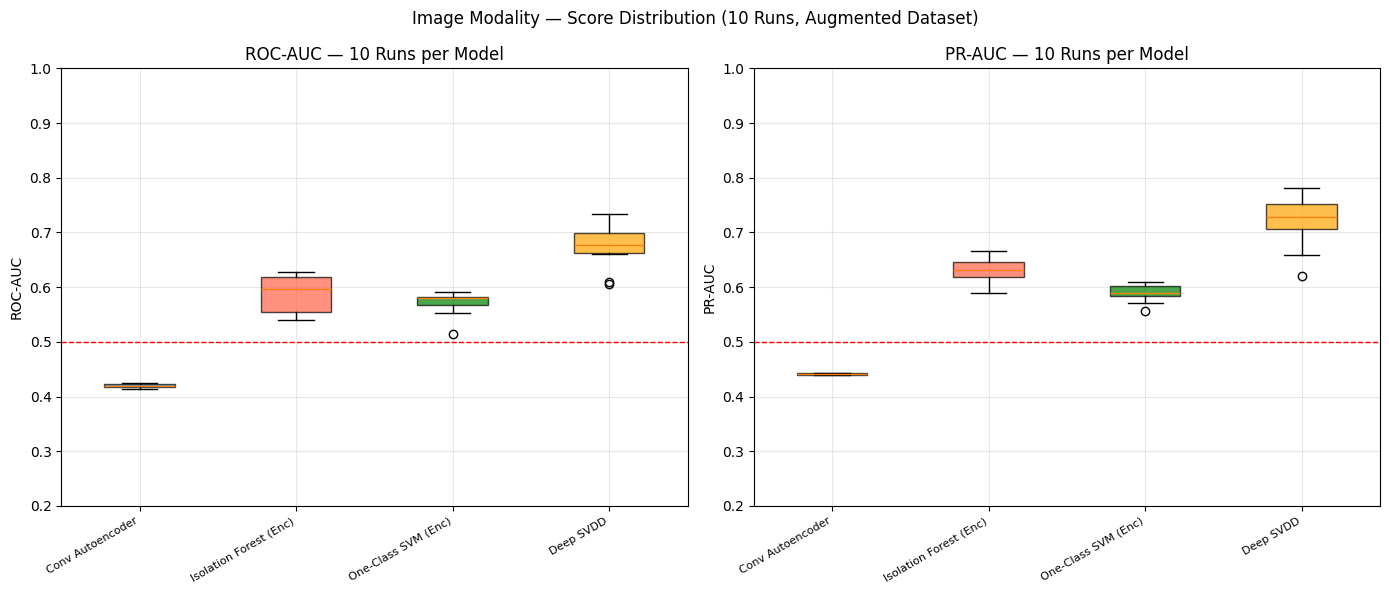

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
model_names = list(image_runs.keys())
colors      = ['steelblue', 'tomato', 'green', 'orange']

for ax, metric in zip(axes, ['ROC-AUC', 'PR-AUC']):
    data = [image_runs[m][metric] for m in model_names]
    bp   = ax.boxplot(data, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1)
    ax.set_title(f'{metric} — 10 Runs per Model')
    ax.set_xticklabels(model_names, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel(metric)
    ax.set_ylim(0.2, 1.0)
    ax.grid(True, alpha=0.3)

plt.suptitle('Image Modality — Score Distribution (10 Runs, Augmented Dataset)', fontsize=12)
plt.tight_layout()
plt.savefig(fr'{BASE}\results\figures\boxplot_image_aug.png', dpi=150)
plt.show()

## 9. Save All Results

In [12]:
with open(fr'{BASE}\results\image_10runs.pkl', 'wb') as f:
    pickle.dump(image_runs, f)

summary_df.to_csv(fr'{BASE}\results\image_summary_10runs.csv')
wilcoxon_df.to_csv(fr'{BASE}\results\wilcoxon_image.csv', index=False)

print('All statistical results saved.')
print('\nSaved files:')
print('  results/image_10runs.pkl')
print('  results/image_summary_10runs.csv')
print('  results/wilcoxon_image.csv')
print('  results/figures/boxplot_image_aug.png')

All statistical results saved.

Saved files:
  results/image_10runs.pkl
  results/image_summary_10runs.csv
  results/wilcoxon_image.csv
  results/figures/boxplot_image_aug.png
